# Task 3 — Clean-Slate EDA

**Status:** automated audits implemented; human judgements are deferred and do not block training.

This notebook implements the five Task 3 audits selected from the [clean-slate research report](../docs/task3_clean_slate_model_research.md). It uses only the teacher dataset, does not train a candidate model, and does not alter `data/processed/splits.csv`. The goal is to decide which pixels, representations, and task structures deserve the next controlled model screen.


## 1. Runtime and leakage contract

Only teacher development images and their development labels may enter target-aware summaries. Every fitted diagnostic probe uses four canonical fold complements and writes a debug, submission-ineligible row through `fashion.train.registry`. Probe scores diagnose shortcut signal on a balanced sample; they are not candidate-model results.


In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as DisplayImage, display
from PIL import Image

def find_repo_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src/fashion').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the cloned repository.')

REPO_DIR = find_repo_root()
os.chdir(REPO_DIR)
if str(REPO_DIR / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_DIR / 'src'))

from fashion.data import load_splits
from fashion.data.splits import cv_assignment_digest
from fashion.data.task3_clean_slate_eda import (
    TASK3_EDA_DIR,
    TASK3_EDA_FIGURE_DIR,
    foreground_views,
    write_clean_slate_eda_tables,
)

TASK3_EDA_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
splits = load_splits()
development = splits[splits['partition'].eq('development')].copy()
contract = pd.DataFrame([{
    'development_rows': len(development),
    'families': development['product_family_group'].nunique(),
    'folds': development['cv_fold'].nunique(),
    'split_digest': cv_assignment_digest(splits),
    'holdout_targets_read': False,
    'image_source': 'teacher_dataset_only',
}])
display(contract)


,development_rows,families,folds,split_digest,holdout_targets_read,image_source
0,32773,22905,5,bad7bc4ae65fbbfd815567f4ccfa308d6e57dc650bc15c...,False,teacher_dataset_only


**Finding.** The notebook sees 32,773 development products in 22,905 family groups and exactly five existing folds. The protected target loader is never imported.


## 2. Execute the five audits

Audit A prepares two independent label-blind review files for possible later use. Their answer key does not exist until both forms pass validation and are locked. The reviews are deferred and do not block training. Audit B measures foreground, background, colour, grayscale, silhouette, and low-dimensional global signal. Audit C checks families and visual components. Audit D tests non-family neighbourhood purity. Audit E measures label-free fold shifts. Cached evidence is reused only when the frozen teacher-data, code, settings, and dependency contract matches.


In [2]:
anchor_candidates = {
    'gender': REPO_DIR / 'results/evidence/task3/experiments/t3_gender_e9_semantic_filter/gender/aggregate/oof_predictions.csv',
    'usage': REPO_DIR / 'results/evidence/task3/experiments/t3_usage_e8_translation/usage/aggregate/oof_predictions.csv',
}
anchor_oof_paths = {target: path for target, path in anchor_candidates.items() if path.is_file()}

task3_eda = write_clean_slate_eda_tables(
    splits=splits,
    output_dir=TASK3_EDA_DIR,
    root=REPO_DIR,
    anchor_oof_paths=anchor_oof_paths,
    run_probes=True,
    run_neighbourhoods=True,
)
display(pd.DataFrame([task3_eda['completion']]))


,created_at_utc,split_digest,audit_contract_hash,artifact_manifest,artifact_manifest_sha256,artifact_count,automated_audits_complete,human_observability_review_complete,human_observability_review_status,holdout_targets_read,image_scope,probe_scope,neighbourhood_scope
0,2026-09-02T11:55:56.077167+00:00,bad7bc4ae65fbbfd815567f4ccfa308d6e57dc650bc15c...,da18800eda834813de427f2288ac2a383a5d0eca3c03e3...,artifact_manifest.csv,fdc18402e263f6765a44b75dbdfea805230a5b91c0bb7...,44,True,False,deferred_non_blocking,False,teacher_development_images_only,balanced development sample; diagnostic only,fold_0_queries_against_other_fold_references


## 3. Audit A — visual observability and label ceiling

The review population contains every ultra-rare usage row plus deterministic family-stratified samples from common usage and every gender class. Each blind form asks separate gender and usage knowability, judgement, and confidence questions. The answer key is created only after both completed forms pass validation and are locked, so labels cannot influence the first judgement.


In [3]:
observability = task3_eda['review']
display(observability['summary'])
display(pd.DataFrame({
    'file': [path.name for path in observability['reviewer_paths']],
    'contains_target_labels': [False, False],
    'status': ['deferred', 'deferred'],
}))
answer_key_status = 'locked and available' if observability['answer_key_path'].is_file() else 'withheld until both forms validate'
print(f'Answer key: {answer_key_status}')


,review_status,unique_images,ultra_rare_usage_rows,common_usage_sample_rows,gender_sample_rows,reviewers_required,labels_exposed_in_reviewer_files
0,deferred_non_blocking,367,143,100,125,2,0


,file,contains_target_labels,status
0,observability_reviewer_1.csv,False,deferred
1,observability_reviewer_2.csv,False,deferred


Answer key: withheld until both forms validate


**Finding.** The pack contains 367 unique teacher images: all 143 ultra-rare usage rows, 100 common-usage sample rows, and 125 gender sample rows, with overlap removed. Both reviewer files expose zero labels. Completing this large blind review is deferred. We therefore make no agreement, kappa, or visually-knowable-rate claim, but the missing human judgement does not block model training.


## 4. Audit B — foreground, background, and global image signal

The foreground rule starts from near-white border pixels and keeps only white pixels connected to that border as background. Empty, tiny, or almost-full proposals fall back to the full frame. The threshold and fallback are label-blind and fixed before any target summary.


,foreground_fraction,foreground_bbox_area_fraction,near_white_fraction,brightness,edge_strength
count,32773.0000,32773.0000,32773.0000,32773.0000,32773.0000
mean,0.3538,0.6032,0.6549,0.8376,0.0311
std,0.1654,0.2122,0.1634,0.0853,0.0132
min,0.0000,0.0885,0.0000,0.1046,0.0000
25%,0.2250,0.4240,0.5452,0.7810,0.0210
50%,0.3594,0.6256,0.6544,0.8440,0.0305
75%,0.4652,0.7667,0.7802,0.9016,0.0391
max,1.0000,1.0000,1.0000,1.0000,0.0968


,rows
foreground_fallback_reason,
no fallback,32248
foreground_too_large,524
empty_or_tiny_foreground,1


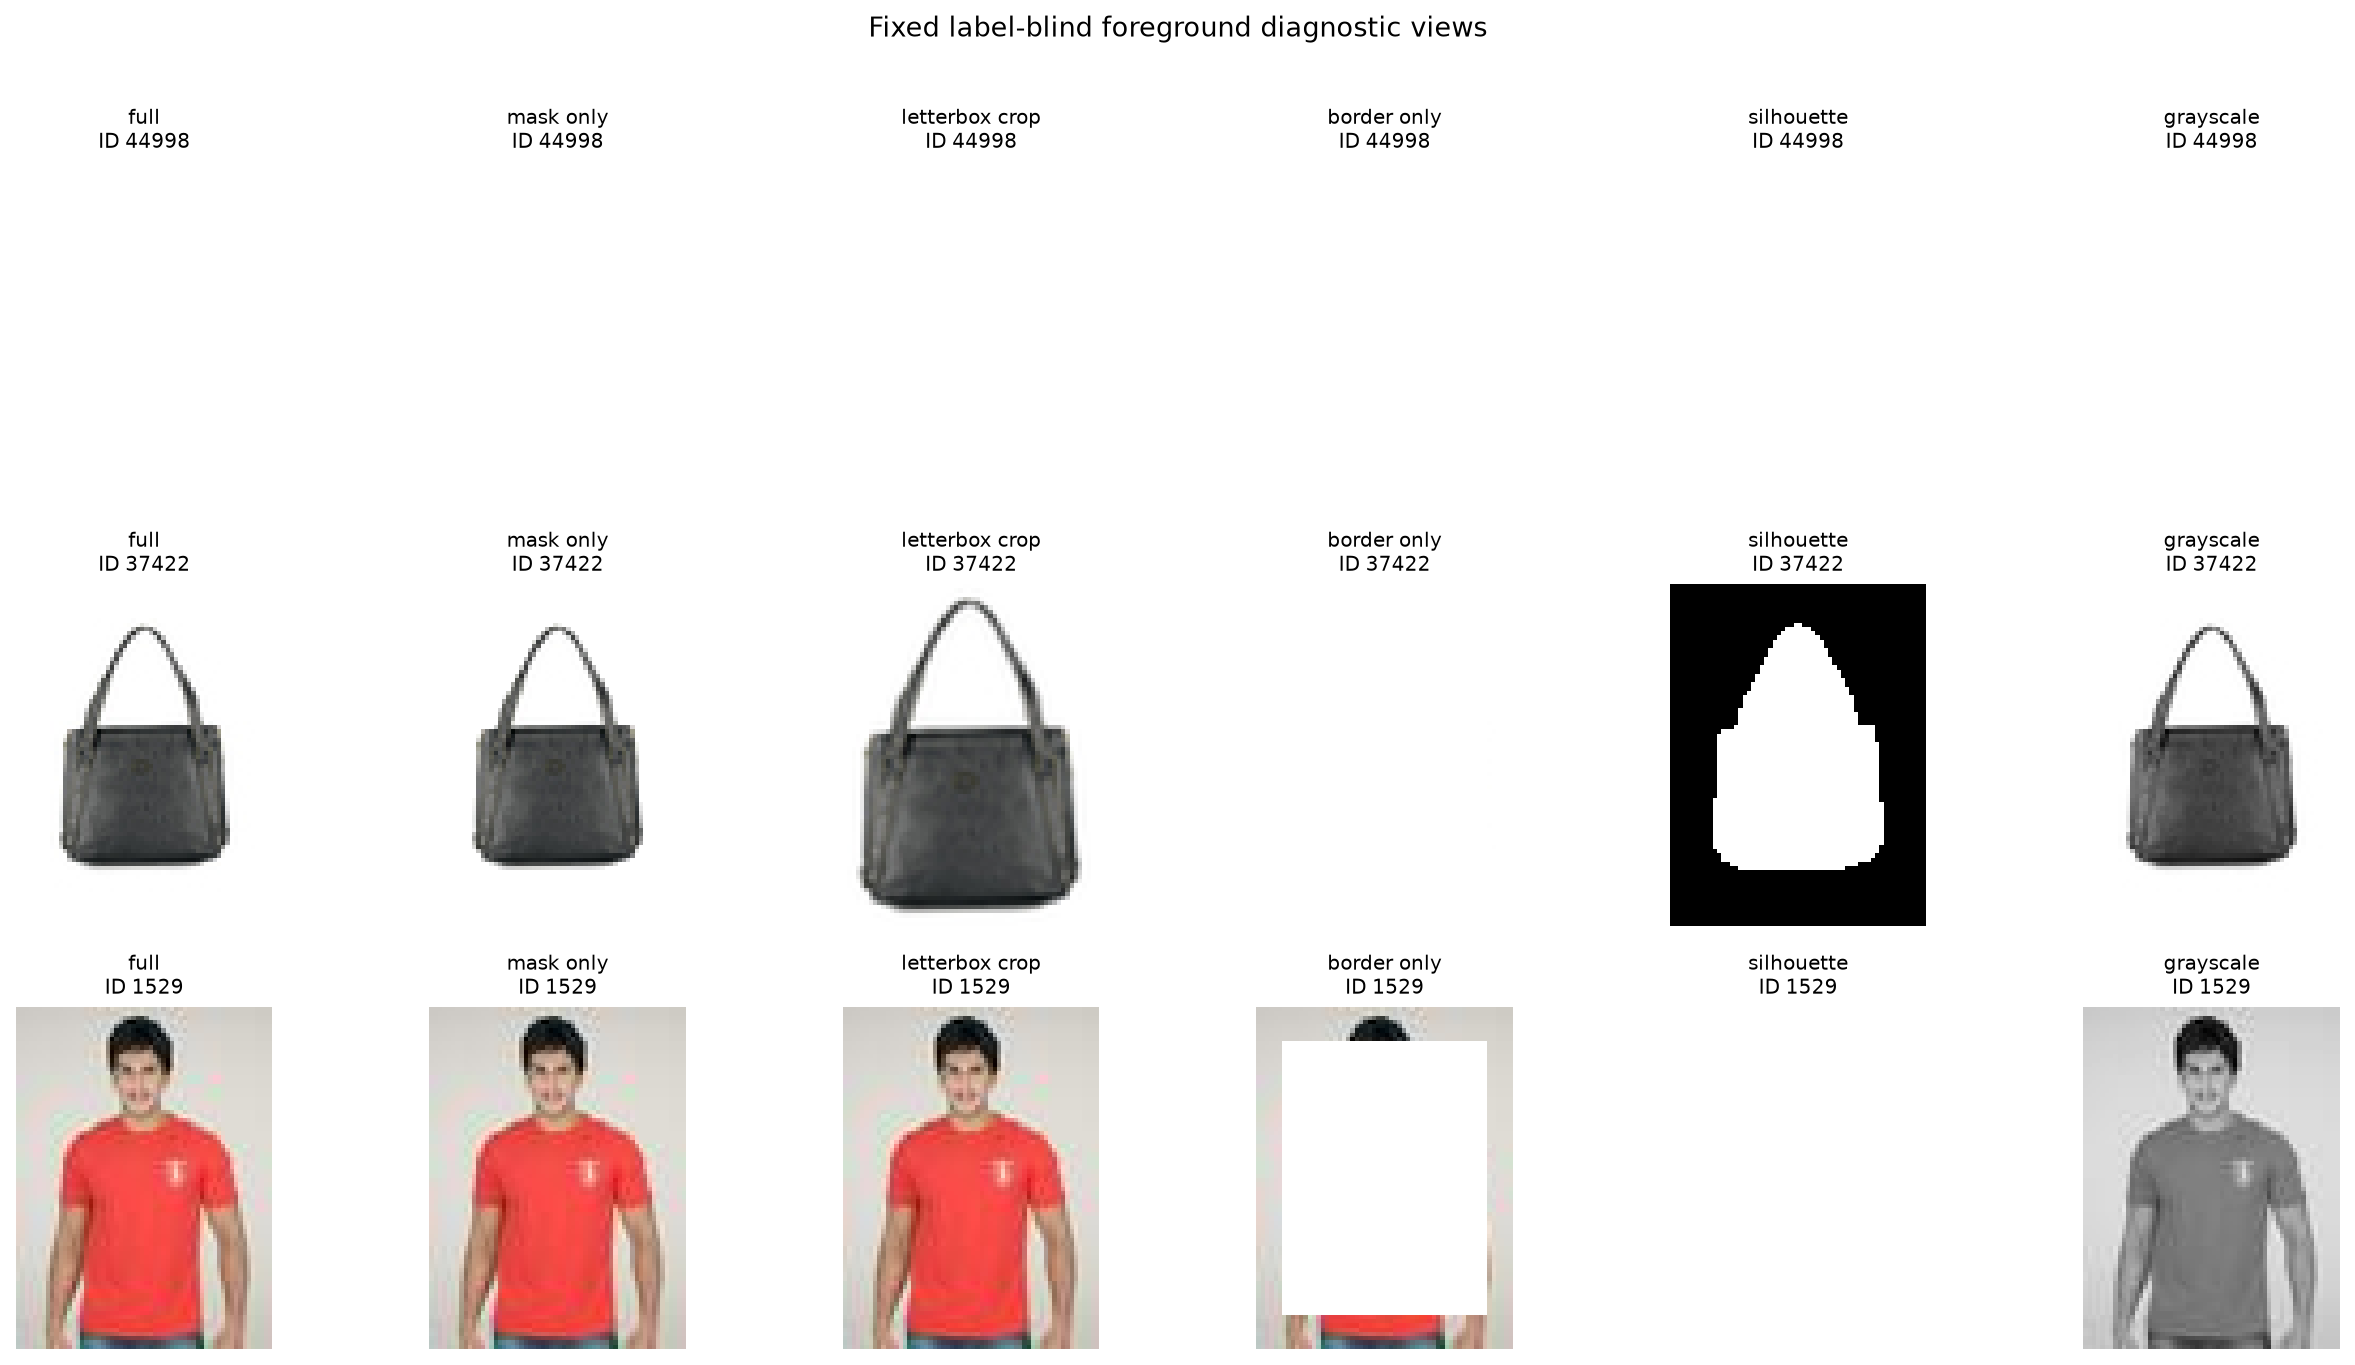

In [4]:
diagnostics = task3_eda['diagnostics']
display(diagnostics[[
    'foreground_fraction', 'foreground_bbox_area_fraction',
    'near_white_fraction', 'brightness', 'edge_strength'
]].describe().round(4))
display(diagnostics['foreground_fallback_reason'].replace('', 'no fallback').value_counts().rename('rows').to_frame())

example_rows = pd.concat([
    diagnostics.nsmallest(1, 'foreground_fraction'),
    diagnostics.iloc[(diagnostics['foreground_fraction'] - diagnostics['foreground_fraction'].median()).abs().argsort()[:1]],
    diagnostics.nlargest(1, 'foreground_fraction'),
    diagnostics[diagnostics['foreground_fallback_reason'].ne('')].head(1),
]).drop_duplicates('id').head(4)

view_names = ['full', 'foreground_masked', 'foreground_letterbox', 'border', 'silhouette', 'grayscale']
view_titles = {'full': 'full', 'foreground_masked': 'mask only', 'foreground_letterbox': 'letterbox crop', 'border': 'border only', 'silhouette': 'silhouette', 'grayscale': 'grayscale'}
figure, axes = plt.subplots(len(example_rows), len(view_names), figsize=(16, 2.8 * len(example_rows)), squeeze=False)
for row_index, row in enumerate(example_rows.itertuples(index=False)):
    with Image.open(REPO_DIR / row.path) as image:
        views = foreground_views(image)
    for column_index, view_name in enumerate(view_names):
        view = views[view_name]
        if view.ndim == 2:
            axes[row_index, column_index].imshow(view, cmap='gray', vmin=0, vmax=255)
        else:
            axes[row_index, column_index].imshow(view)
        axes[row_index, column_index].set_title(f'{view_titles[view_name]}\nID {row.id}', fontsize=9)
        axes[row_index, column_index].axis('off')
figure.suptitle('Fixed label-blind foreground diagnostic views', y=1.01)
figure.tight_layout()
foreground_figure = TASK3_EDA_FIGURE_DIR / 'foreground_diagnostic_views.png'
figure.savefig(foreground_figure, dpi=160, bbox_inches='tight')
plt.close(figure)
display(DisplayImage(filename=str(foreground_figure)))


,batch_id,canonical_fold_runs
0,ff6d4df37815663b,80


,target,feature,global_eta_squared,within_article_type_eta_squared,absolute_median_shift
9,gender,foreground_height_fraction,0.0377,0.2329,0.4000
7,gender,foreground_bbox_area_fraction,0.0649,0.1617,0.3323
3,gender,edge_strength,0.0658,0.1046,0.0169
6,gender,foreground_fraction,0.0498,0.0909,0.1940
5,gender,border_connected_white_fraction,0.0498,0.0909,0.1940
4,gender,near_white_fraction,0.0508,0.0867,0.1851
14,gender,blue_mean,0.0560,0.0867,0.1028
1,gender,brightness,0.0656,0.0831,0.1055
26,usage,foreground_width_fraction,0.0702,0.0109,0.3167
24,usage,foreground_fraction,0.0043,0.0093,0.7648


,target,view,sample_rows,pooled_macro_f1,accuracy,fold_macro_f1_sd,interpretation
0,gender,foreground_masked_hog,4483,0.6814,0.7033,0.0183,relative shortcut probe on balanced sample; no...
1,gender,grayscale_hog,4483,0.6752,0.6948,0.0202,relative shortcut probe on balanced sample; no...
2,gender,full_rgb_hog,4483,0.6736,0.6955,0.0267,relative shortcut probe on balanced sample; no...
3,gender,silhouette_hog,4483,0.6616,0.6819,0.0212,relative shortcut probe on balanced sample; no...
4,gender,foreground_letterbox_hog,4483,0.6326,0.6589,0.0218,relative shortcut probe on balanced sample; no...
5,gender,colour_summary,4483,0.5351,0.5521,0.0138,relative shortcut probe on balanced sample; no...
6,gender,border_hog,4483,0.5082,0.5550,0.0148,relative shortcut probe on balanced sample; no...
7,gender,global_geometry_colour,4483,0.4784,0.4974,0.0106,relative shortcut probe on balanced sample; no...
8,usage,full_rgb_hog,4878,0.4541,0.7515,0.0499,relative shortcut probe on balanced sample; no...
9,usage,foreground_masked_hog,4878,0.4440,0.7483,0.0467,relative shortcut probe on balanced sample; no...


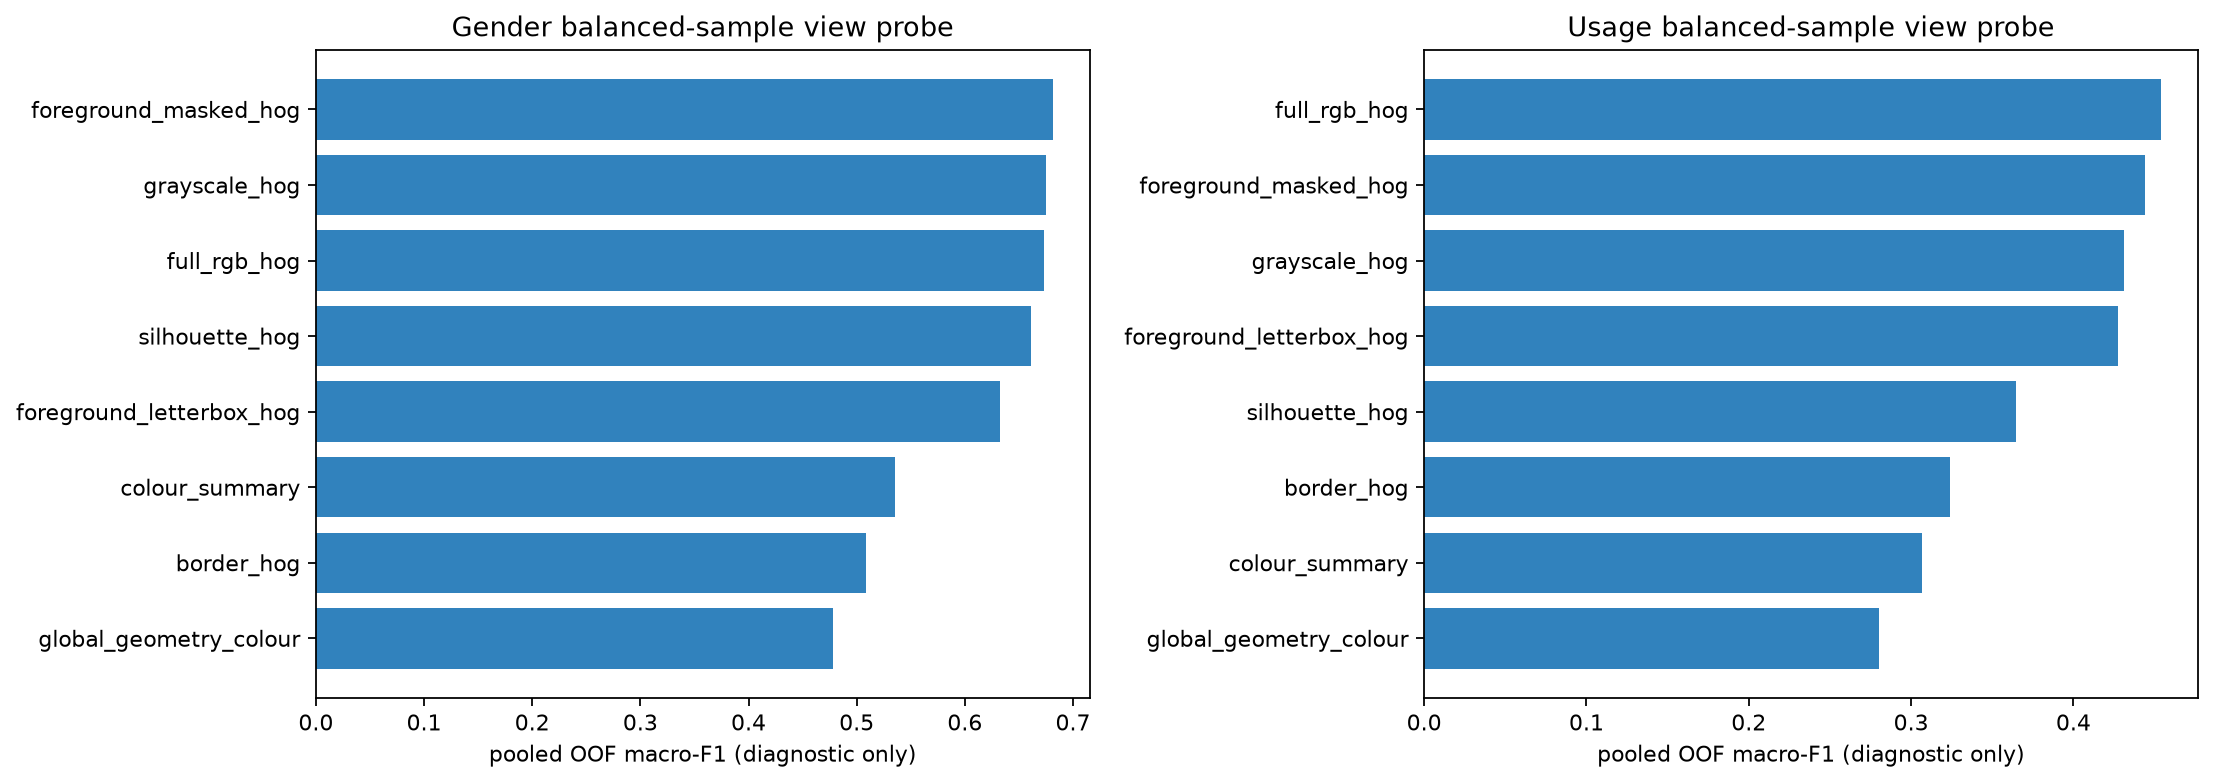

In [5]:
nuisance = task3_eda['nuisance']
probe_summary = task3_eda['probe_summary']
probe_contract = json.loads((TASK3_EDA_DIR / 'view_probes/view_probe_contract.json').read_text())
display(pd.DataFrame([{'batch_id': probe_contract['batch_id'], 'canonical_fold_runs': len(task3_eda['probe_folds'])}]))
display(nuisance.groupby('target').head(8).round(4))
display(probe_summary.round(4))

figure, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
for axis, target in zip(axes, ('gender', 'usage'), strict=True):
    table = probe_summary[probe_summary['target'].eq(target)].sort_values('pooled_macro_f1')
    axis.barh(table['view'], table['pooled_macro_f1'], color='#3182bd')
    axis.set_title(f'{target.title()} balanced-sample view probe')
    axis.set_xlabel('pooled OOF macro-F1 (diagnostic only)')
figure.tight_layout()
probe_figure = TASK3_EDA_FIGURE_DIR / 'diagnostic_view_probes.png'
figure.savefig(probe_figure, dpi=160, bbox_inches='tight')
plt.close(figure)
display(DisplayImage(filename=str(probe_figure)))


**Finding.** The fixed foreground rule uses its safe full-frame fallback on 525 of 32,773 images: 524 images have foreground covering almost the whole canvas and one is empty or tiny. Twelve teacher images have a non-standard shape, so probe inputs are resized to the fixed 60×80 canvas while their original geometry remains recorded. On the balanced diagnostic sample, mask-only HOG is strongest for gender (pooled macro-F1 0.6814), slightly above grayscale (0.6752) and full RGB (0.6736). The aspect-preserving letterbox crop falls to 0.6326, so enlarging and repositioning the object is harmful even without stretching it. Full RGB HOG is strongest for usage (0.4541), ahead of mask-only (0.4440), grayscale (0.4314), and letterbox crop (0.4276). Border-only and low-dimensional global/geometry/colour probes remain predictive—gender 0.5082/0.4784 and usage 0.3239/0.2802. This shows shortcut risk, but it does not prove that every global feature is unwanted noise. After article-type medians are removed, gender still has a large association with foreground height (eta-squared 0.2329), while usage's largest remaining association is only 0.0109. These diagnostic scores must not be compared directly with full-population E1–E10 scores.


## 5. Audit C — duplicates, families, and sample unit

The primary validation population remains product-weighted. Component weighting is measured only as a possible training policy. Historical anchor OOF predictions are used, when locally available, to test whether larger families have different error or confidence patterns.


,unit,development_rows,unique_units,fold_crossings,largest_unit
0,product_family_group,32773,22905,0,80
1,duplicate_group,32773,32121,0,4


,size_band,families,products
0,1,19043,19043
1,2,2138,4276
2,3-5,1259,4568
3,6+,465,4886


,target,class_name,row_count,row_share,component_weighted_support,component_weighted_share
0,gender,Boys,684,0.02087,489.0,0.01522
1,gender,Girls,543,0.01657,406.0,0.01264
2,gender,Men,17753,0.54170,17475.0,0.54404
3,gender,Unisex,1766,0.05389,1766.0,0.05498
4,gender,Women,12027,0.36698,11985.0,0.37312
5,usage,Casual,25151,0.76745,24585.0,0.76541
6,usage,Ethnic,2183,0.06661,2180.0,0.06787
7,usage,Formal,1949,0.05947,1869.0,0.05819
8,usage,Home,1,0.00003,1.0,0.00003
9,usage,NA,61,0.00186,60.0,0.00187


,target,size_band,rows,accuracy,macro_f1,mean_confidence,wrong_mean_confidence
0,gender,1,19043,0.8801,0.7245,0.9546,0.8242
1,gender,2,4276,0.8835,0.7140,0.9542,0.8092
2,gender,3-5,4568,0.9046,0.7715,0.9589,0.8006
3,gender,6+,4886,0.9406,0.8525,0.9709,0.8318
4,usage,1,19042,0.8738,0.4085,0.8806,0.7413
5,usage,2,4276,0.9013,0.4586,0.8889,0.7286
6,usage,3-5,4568,0.9131,0.3642,0.8958,0.7179
7,usage,6+,4886,0.9118,0.3590,0.8990,0.7402


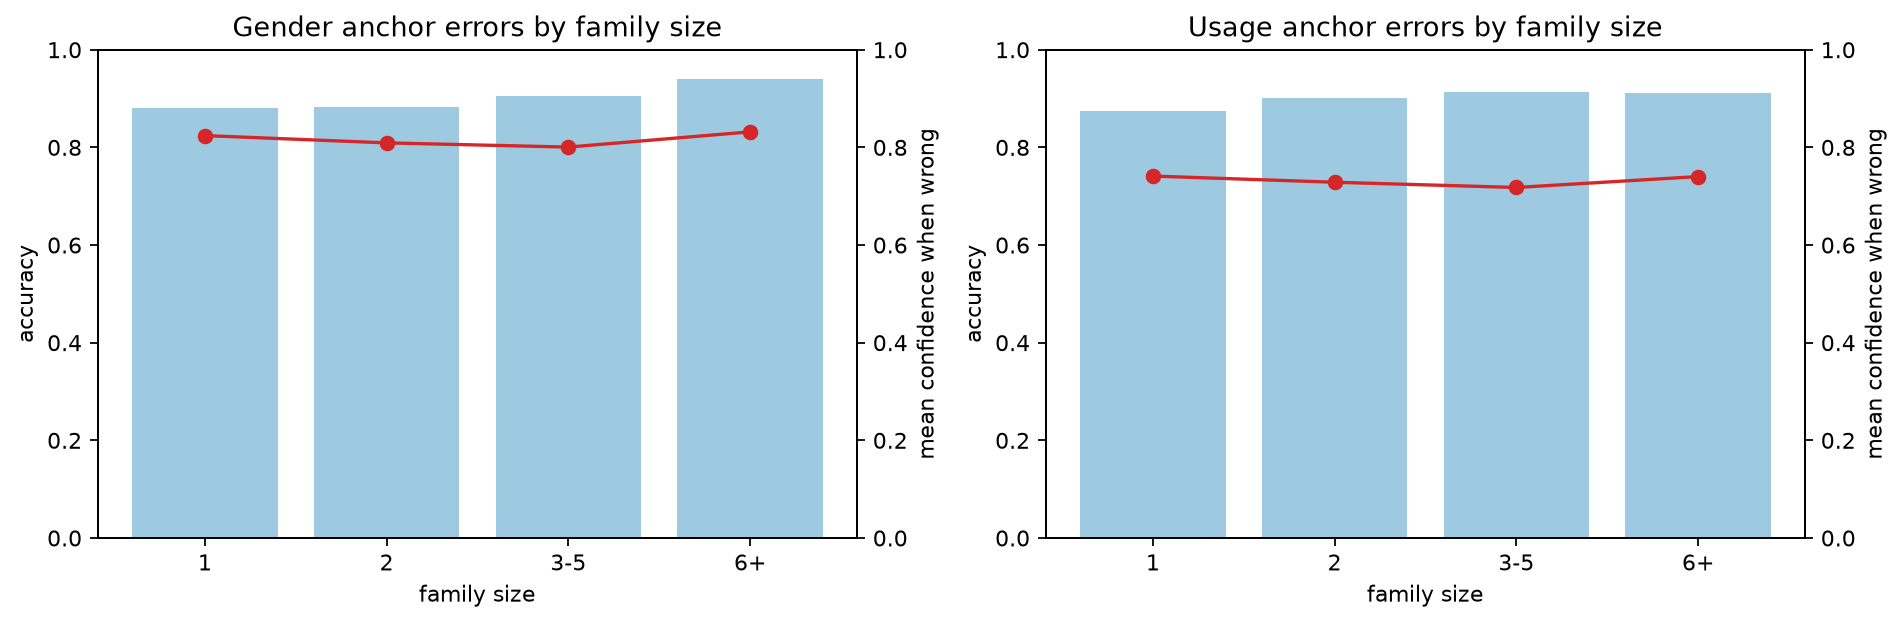

In [6]:
family = task3_eda['family']
display(family['boundary'])
display(family['family_profile'])
display(family['component_weights'].round(5))
if not family['anchor_error_slices'].empty:
    display(family['anchor_error_slices'].round(4))
    figure, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    for axis, target in zip(axes, ('gender', 'usage'), strict=True):
        table = family['anchor_error_slices'][family['anchor_error_slices']['target'].eq(target)]
        axis.bar(table['size_band'], table['accuracy'], color='#9ecae1', label='accuracy')
        confidence_axis = axis.twinx()
        confidence_axis.plot(table['size_band'], table['wrong_mean_confidence'], color='#d62728', marker='o', label='wrong confidence')
        confidence_axis.set_ylim(0, 1)
        confidence_axis.set_ylabel('mean confidence when wrong')
        axis.set_title(f'{target.title()} anchor errors by family size')
        axis.set_xlabel('family size')
        axis.set_ylim(0, 1)
        axis.set_ylabel('accuracy')
    figure.tight_layout()
    family_figure = TASK3_EDA_FIGURE_DIR / 'anchor_family_size_slices.png'
    figure.savefig(family_figure, dpi=160, bbox_inches='tight')
    plt.close(figure)
    display(DisplayImage(filename=str(family_figure)))
else:
    print('Historical anchor OOF files were not present; structural family checks still completed.')


**Finding.** Both product-family and exact/accepted duplicate groups have zero fold crossings. The 32,773 development rows contain 22,905 families and 32,121 duplicate components. Exact component weighting barely changes the large class shares, so it is unlikely to solve usage imbalance by itself. Historical OOF errors are lower in larger families for gender (accuracy 0.8801 for singletons versus 0.9406 for families of six or more), showing that repeated family evidence makes the task easier. The official validation metric must remain product-weighted.


## 6. Audit D — representation neighbourhoods

Fold-0 queries search only reference images from folds 1–4, so same-family neighbours are impossible under the verified split. Raw pixels, HOG, fixed scattering, and fold-training-only Fisher vectors are compared using the same query/reference scope. The result tests whether any representation naturally clusters the labels before a full classifier experiment.


,target,representation,query_fold,reference_rows,query_rows,top1_label_purity,top5_label_purity,same_family_neighbours
0,gender,hog,0,1250,449,0.6971,0.6200,0
1,gender,raw_pixels,0,1250,449,0.6570,0.5653,0
2,gender,fisher,0,1250,449,0.6303,0.5439,0
3,gender,scattering,0,1250,449,0.3875,0.3697,0
4,usage,hog,0,1096,423,0.7305,0.6771,0
5,usage,raw_pixels,0,1096,423,0.7045,0.6317,0
6,usage,fisher,0,1096,423,0.6927,0.6175,0
7,usage,scattering,0,1096,423,0.5130,0.4293,0


,target,representation,slice_type,slice_value,rows,top1_label_purity,top5_label_purity
0,gender,raw_pixels,class,Boys,79,0.6203,0.5165
1,gender,raw_pixels,class,Girls,70,0.8143,0.6943
2,gender,raw_pixels,class,Men,100,0.7400,0.6520
3,gender,raw_pixels,class,Unisex,100,0.6200,0.5640
4,gender,raw_pixels,class,Women,100,0.5300,0.4280
8,gender,hog,class,Boys,79,0.6709,0.6456
9,gender,hog,class,Girls,70,0.7714,0.6343
10,gender,hog,class,Men,100,0.7800,0.6800
11,gender,hog,class,Unisex,100,0.6300,0.6040
12,gender,hog,class,Women,100,0.6500,0.5460


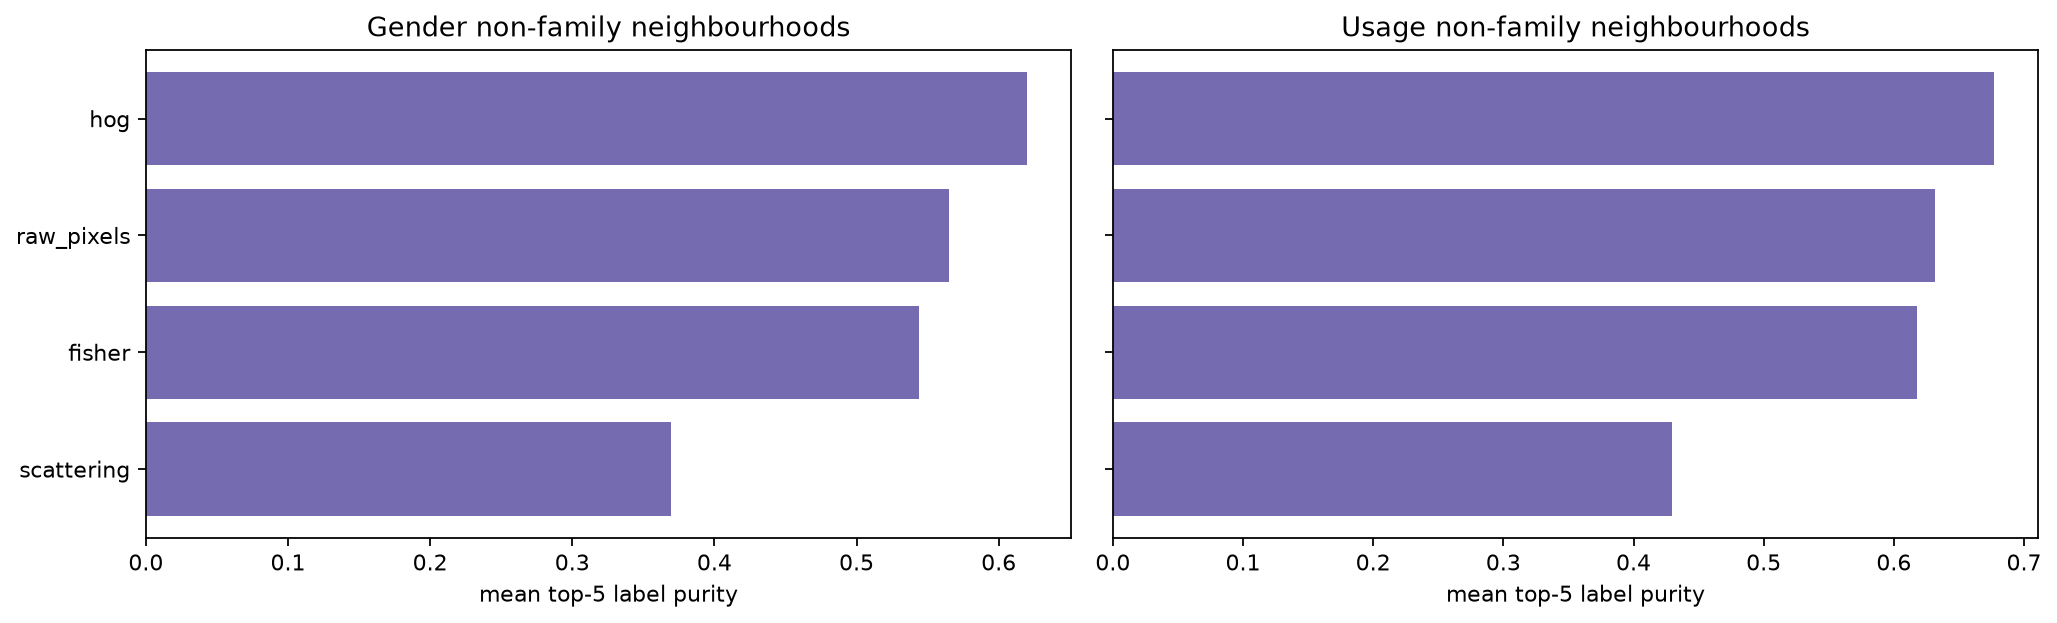

In [7]:
neighbourhoods = task3_eda['neighbourhood_summary']
neighbourhood_slices = task3_eda['neighbourhood_slices']
display(neighbourhoods.round(4))
display(neighbourhood_slices[neighbourhood_slices['slice_type'].eq('class')].round(4))

figure, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ('gender', 'usage'), strict=True):
    table = neighbourhoods[neighbourhoods['target'].eq(target)].sort_values('top5_label_purity')
    axis.barh(table['representation'], table['top5_label_purity'], color='#756bb1')
    axis.set_title(f'{target.title()} non-family neighbourhoods')
    axis.set_xlabel('mean top-5 label purity')
figure.tight_layout()
neighbour_figure = TASK3_EDA_FIGURE_DIR / 'representation_neighbourhood_purity.png'
figure.savefig(neighbour_figure, dpi=160, bbox_inches='tight')
plt.close(figure)
display(DisplayImage(filename=str(neighbour_figure)))


**Finding.** After removing all same-family neighbours, HOG has the best top-1/top-5 label purity for both gender (0.6971/0.6200) and usage (0.7305/0.6771). Raw pixels and Fisher vectors trail it, while the tested scattering summary is weakest (gender 0.3875/0.3697; usage 0.5130/0.4293). This supports completing a HOG-based classical reference before promoting scattering or prototype methods. It is still a neighbourhood diagnostic, not a final classifier score.


## 7. Audit E — fold artifacts

For each label-free image feature, the notebook compares one fixed fold with the other four using Jensen–Shannon divergence and a standardised mean shift. The folds are never repaired after seeing these values; the audit only explains instability.


,fold,feature,jensen_shannon_divergence,standardized_mean_shift,fold_median,other_folds_median
15,0,edge_strength,0.00085,0.00614,0.03061,0.03045
72,2,blue_mean,0.00078,-0.01140,0.83315,0.83518
65,0,green_mean,0.00075,-0.00538,0.84089,0.84131
25,0,border_connected_white_fraction,0.00062,0.00435,0.64125,0.64042
63,3,red_mean,0.00062,-0.01921,0.85800,0.85976
18,3,edge_strength,0.00061,-0.00596,0.03041,0.03050
30,0,foreground_fraction,0.00060,-0.00435,0.35875,0.35958
35,0,foreground_bbox_area_fraction,0.00059,-0.00655,0.62500,0.62615
83,3,value_mean,0.00059,-0.01722,0.87162,0.87290
48,3,foreground_height_fraction,0.00056,0.00356,0.88750,0.88750


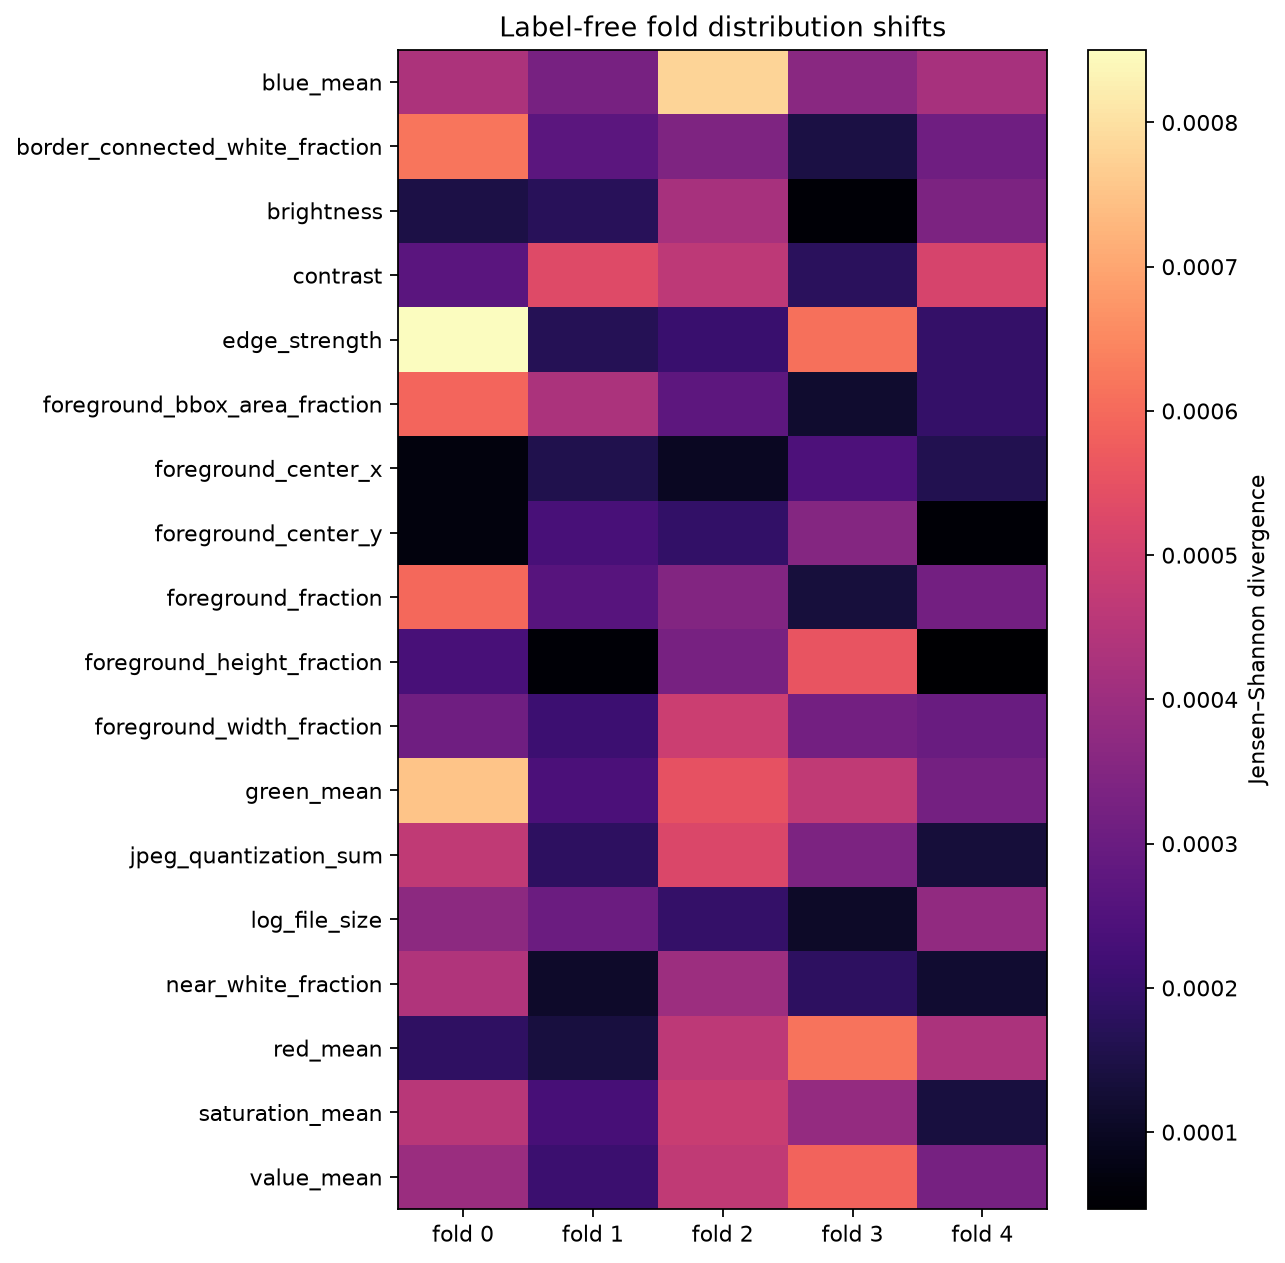

In [8]:
fold_shifts = task3_eda['fold_shifts']
display(fold_shifts.head(20).round(5))
heatmap = fold_shifts.pivot(index='feature', columns='fold', values='jensen_shannon_divergence')
figure, axis = plt.subplots(figsize=(8, 8))
image = axis.imshow(heatmap.to_numpy(), aspect='auto', cmap='magma')
axis.set_xticks(range(len(heatmap.columns)), [f'fold {fold}' for fold in heatmap.columns])
axis.set_yticks(range(len(heatmap.index)), heatmap.index)
axis.set_title('Label-free fold distribution shifts')
figure.colorbar(image, ax=axis, label='Jensen–Shannon divergence')
figure.tight_layout()
fold_figure = TASK3_EDA_FIGURE_DIR / 'fold_artifact_shifts.png'
figure.savefig(fold_figure, dpi=160, bbox_inches='tight')
plt.close(figure)
display(DisplayImage(filename=str(fold_figure)))


**Finding.** The fixed folds are well balanced on the 18 measured global image properties. The largest Jensen–Shannon divergence is only 0.00085 (fold 0 edge strength), and the largest absolute standardised mean shift is 0.0282 (fold 1 foreground vertical centre). These measured marginal properties do not explain the much larger model score spread. This does not rule out finer joint or semantic shifts, and the canonical folds stay unchanged.


## 8. EDA decision gate

The automated evidence is complete enough to start controlled model screens. The human label ceiling remains unknown until the two blind reviews are completed, so the observability gate stays visible as deferred rather than being replaced by model guesses. It is not a training blocker. Gender and usage now take separate model paths because their evidence points to different problems.


In [9]:
gate = pd.DataFrame([
    {'item': 'canonical split unchanged', 'status': 'pass', 'next_action': 'keep all five folds'},
    {'item': 'automated image/family/fold audits', 'status': 'pass', 'next_action': 'use findings for model screens'},
    {'item': 'two independent observability reviews', 'status': 'deferred', 'next_action': 'optional later; not a training blocker'},
])
display(gate)
print(f'Evidence directory: {TASK3_EDA_DIR}')
print(f'Figure directory: {TASK3_EDA_FIGURE_DIR}')


,item,status,next_action
0,canonical split unchanged,pass,keep all five folds
1,automated image/family/fold audits,pass,use findings for model screens
2,two independent observability reviews,deferred,optional later; not a training blocker


Evidence directory: /home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/results/evidence/task3/clean_slate_eda
Figure directory: /home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/results/figures/task3/clean_slate_eda


**Completion result.** Every automated teacher-only audit above completed without an error. The two-reviewer observability study is explicitly deferred and is not a training blocker. The next screen uses separate models: fixed HOG + colour/shape with a calibrated SVM for gender, and an image-derived article-type probability model followed by a fold-fitted type-to-usage probability map for usage. No candidate model was accepted or trained by this notebook.
